Logistic Regression CV ROC-AUC: 0.8450423904827902


Random Forest CV ROC-AUC: 0.8232305879335321


/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:46:44] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:46:44] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:46:44] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:46:45] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iterati

XGBoost CV ROC-AUC: 0.8249050238526326
Best RF params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best RF ROC-AUC: 0.84274110833279


/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:47:01] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:47:01] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:47:01] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:47:01] WARNING: /croot/xgboost-split_1749630910898/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iterati

Best XGB params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best XGB ROC-AUC: 0.8496965006842944


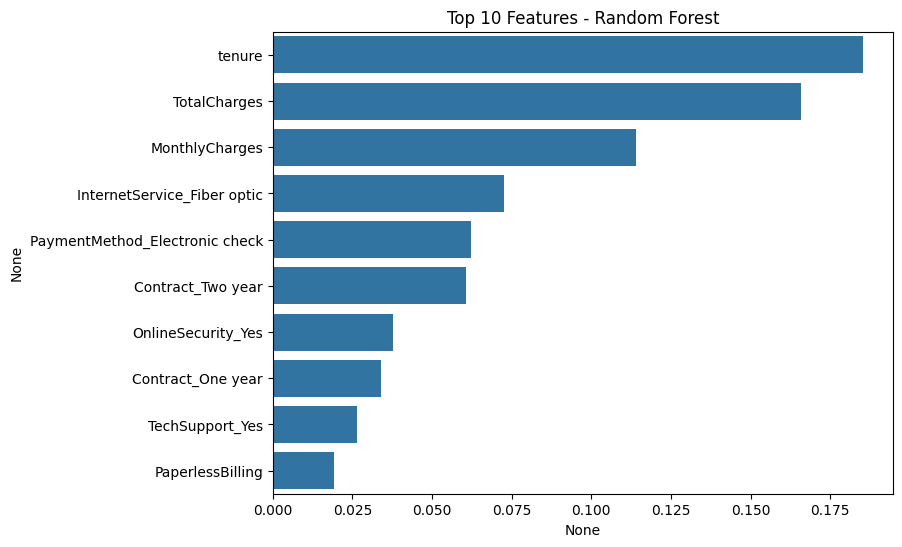

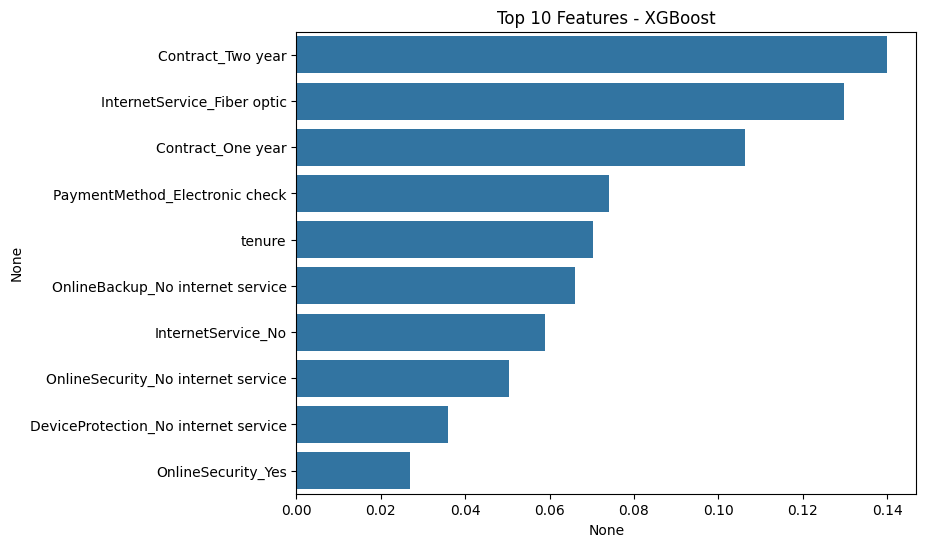


Random Forest Final Evaluation
Accuracy: 0.7931769722814499
Precision: 0.636963696369637
Recall: 0.516042780748663
F1: 0.5701624815361891
ROC-AUC: 0.8349169906455939

XGBoost Final Evaluation
Accuracy: 0.7967306325515281
Precision: 0.6506849315068494
Recall: 0.5080213903743316
F1: 0.5705705705705706
ROC-AUC: 0.8419069114929261

Final model saved to ../models/final_churn_model.pkl


In [3]:
# --------------------------
# Day 5: Model Selection & Tuning
# --------------------------

# 0. Imports
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# --------------------------
# 1. Reload & Preprocess Data
# --------------------------
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df = df.drop("customerID", axis=1)

# Fix TotalCharges (convert to numeric, drop blanks)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Encode Yes/No
binary_map = {"Yes": 1, "No": 0}
for col in df.columns:
    if set(df[col].unique()) <= {"Yes", "No"}:
        df[col] = df[col].map(binary_map)

# One-hot encode categoricals
categorical_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Scale numerics
scaler = StandardScaler()
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Train/test split
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --------------------------
# 2. Cross-Validation
# --------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

print("Logistic Regression CV ROC-AUC:", cross_val_score(log_reg, X, y, cv=cv, scoring="roc_auc").mean())
print("Random Forest CV ROC-AUC:", cross_val_score(rf, X, y, cv=cv, scoring="roc_auc").mean())
print("XGBoost CV ROC-AUC:", cross_val_score(xgb, X, y, cv=cv, scoring="roc_auc").mean())

# --------------------------
# 3. Hyperparameter Tuning
# --------------------------

# Random Forest GridSearch
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
grid_rf = GridSearchCV(
    rf, param_grid_rf, cv=3, scoring="roc_auc", n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print("Best RF params:", grid_rf.best_params_)
print("Best RF ROC-AUC:", grid_rf.best_score_)

# XGBoost RandomizedSearch
param_dist_xgb = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}
random_xgb = RandomizedSearchCV(
    xgb, param_dist_xgb, cv=3, scoring="roc_auc", n_iter=10, random_state=42, n_jobs=-1
)
random_xgb.fit(X_train, y_train)
print("Best XGB params:", random_xgb.best_params_)
print("Best XGB ROC-AUC:", random_xgb.best_score_)

# --------------------------
# 4. Feature Importance
# --------------------------

# Random Forest Feature Importance
importances_rf = grid_rf.best_estimator_.feature_importances_
feat_rf = pd.Series(importances_rf, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_rf[:10], y=feat_rf.index[:10])
plt.title("Top 10 Features - Random Forest")
plt.show()

# XGBoost Feature Importance
importances_xgb = random_xgb.best_estimator_.feature_importances_
feat_xgb = pd.Series(importances_xgb, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_xgb[:10], y=feat_xgb.index[:10])
plt.title("Top 10 Features - XGBoost")
plt.show()

# --------------------------
# 5. Final Model Selection & Save
# --------------------------
# Evaluate best tuned models
rf_best = grid_rf.best_estimator_
xgb_best = random_xgb.best_estimator_

for name, model in [("Random Forest", rf_best), ("XGBoost", xgb_best)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} Final Evaluation")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Save final model (choose XGBoost as example)
joblib.dump(xgb_best, "../models/final_churn_model.pkl")
print("\nFinal model saved to ../models/final_churn_model.pkl")
